# Checking whether $P=IV$

The goal of this notebook is to check whether $P=IV$ (or $P=cIV$) for various systems. 
It is potentially a bad idea to compare systems where $P=IV$ and $P\neq IV$

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pyarrow as pa  # not yet needed, might need it later
import pyarrow.parquet as pq
import pyarrow.compute as pc  # not yet needed, might need it later.
import os
import random


all_systems = pd.read_csv('data/core/systems_cleaned.csv')
all_systems = all_systems.loc[all_systems['has_power_data'] & all_systems['has_current_data'] & all_systems['has_voltage_data']]
all_systems = all_systems[['system_id', 'has_power_data', 'has_current_data', 'has_voltage_data']]
all_systems


metrics_dir = Path('data/raw/parquet-metrics/')
# Note: We generally give a directory, rather than an individual file, to the next step.
metrics_pq = pq.ParquetDataset(metrics_dir)
metrics_df = metrics_pq.read().to_pandas()
metrics_df


# actually, want to keep only the system_id that we have data downloaded for
# the data for these systems is in the folders in '../data_ds_project/systems/parquet'
data_dir = '../data_ds_project/systems/parquet'

#list of folder names - aka system_ids we have parquet data downloaded for
folder_names = [
    name for name in os.listdir(data_dir)
]
# filter metrics_df to only include rows where system_id is in folder_names
metrics_df_filtered = metrics_df[metrics_df['system_id'].astype(str).isin(folder_names)]
metrics_df_filtered



#likely want a list of the system_ids we have data for (as integers - otherwise would use folder_names)
system_ids = [int(name) for name in folder_names]
#now sort them 
system_ids = sorted(system_ids)
system_ids

[2,
 3,
 4,
 10,
 33,
 34,
 35,
 36,
 50,
 51,
 1199,
 1200,
 1201,
 1202,
 1203,
 1204,
 1207,
 1208,
 1214,
 1216,
 1217,
 1218,
 1219,
 1220,
 1221,
 1222,
 1223,
 1224,
 1225,
 1226,
 1228,
 1229,
 1230,
 1231,
 1239,
 1244,
 1245,
 1246,
 1248,
 1249,
 1250,
 1252,
 1253,
 1254,
 1255,
 1256,
 1257,
 1258,
 1259,
 1260,
 1261,
 1262,
 1263,
 1264,
 1265,
 1266,
 1267,
 1268,
 1269,
 1270,
 1271,
 1272,
 1273,
 1274,
 1275,
 1276,
 1277,
 1278,
 1283,
 1284,
 1289,
 1294,
 1295,
 1296,
 1297,
 1298,
 1299,
 1300,
 1301,
 1302,
 1303,
 1304,
 1305,
 1306,
 1307,
 1308,
 1309,
 1310,
 1311,
 1312,
 1314,
 1315,
 1316,
 1317,
 1318,
 1319,
 1320,
 1321,
 1322,
 1323,
 1324,
 1325,
 1326,
 1328,
 1329,
 1330,
 1331,
 1332,
 1334,
 1335,
 1336,
 1337,
 1338,
 1339,
 1340,
 1342,
 1343,
 1344,
 1345,
 1346,
 1347,
 1348,
 1349,
 1350,
 1351,
 1352,
 1353,
 1354,
 1355,
 1356,
 1357,
 1358,
 1359,
 1360,
 1361,
 1362,
 1363,
 1364,
 1367,
 1368,
 1369,
 1403,
 1416,
 1418,
 1419,
 1420,
 

Things that need to get done:
- iterate through systems
- for each system, need ALL of power, current, and voltage
    - so might be a good idea to first check which systems have all three
- For each of those systems, 
    - figure out metric_id's for each thing
    - see what the units are
    - data clean-up
        - drop repeat rows
        - average false repeat rows
        - remove extra columns
        - drop repeat rows again
        - keep only rows with >1amp, >1 volt, >=5 W
    - calculate theoretical power, add it as a column
    - plot actual recorded power (x-axis) vs theoretical power (y-axis)



Now, have to check what the metric_id's are for each of those things. The problem: might have to choose 1 (they may have multiple)

In [ ]:
#start with first system_id!
id = system_ids[0]

df_metric = metrics_df_filtered.loc[metrics_df_filtered['system_id'] == id]
#write down metric_ids for current, voltage, power for this system_id
current_id = 348
voltage_id = 347
power_id = 346
power_common_name = metrics_df_filtered.loc[metrics_df_filtered['metric_id'] == power_id, 'common_name'].values[0]
id_path = Path(data_dir) / str(id)
df_metric

df_system = pd.read_parquet(id_path) #read it in
df_system =df_system.drop(columns=["utc_measured_on"]) #not interested
df_system = df_system.drop_duplicates() #don't want duplicates
df_system = df_system.loc[df_system['metric_id'].isin([current_id, voltage_id, power_id])] #only want relevant metric_ids

df_system_wide = df_system.pivot(index='measured_on', columns='metric_id', values='value')
#get rid of negative values
df_system_wide = df_system_wide[(df_system_wide[current_id] >= 1) & (df_system_wide[voltage_id] >= 1) & (df_system_wide[power_id] >= 1)]
df_system_wide

#make a power vs IV plot
plt.scatter(df_system_wide[current_id] * df_system_wide[voltage_id], df_system_wide[power_id], alpha=0.5)
plt.xlabel('Theoretical power = Current * Voltage')
plt.ylabel('Recorded Power')
plt.title(f'System ID {id} - Power vs IV DC')

#also plot line y=x for reference
plt.plot([0, df_system_wide[current_id].max() * df_system_wide[voltage_id].max()], [0, df_system_wide[current_id].max() * df_system_wide[voltage_id].max()], color='red', linestyle='--', label='y=x reference')
plt.legend()


In [ ]:
#second system_id
id = system_ids[1]

df_metric = metrics_df_filtered.loc[metrics_df_filtered['system_id'] == id]


dc_or_ac = 'tbd' 

if df_metric['common_name'].duplicated().any():
    print('Duplicate common names found for this system_id. Please check by hand.')
else:
    if ('DC power' in df_metric['common_name'].values) & ('DC current' in df_metric['common_name'].values) & ('DC voltage' in df_metric['common_name'].values):
        current_id = df_metric.loc[df_metric['common_name'] == 'DC current', 'metric_id'].values[0]
        voltage_id = df_metric.loc[df_metric['common_name'] == 'DC voltage', 'metric_id'].values[0]
        power_id = df_metric.loc[df_metric['common_name'] == 'DC power', 'metric_id'].values[0]
        dc_or_ac = 'DC'
    elif ('AC power' in df_metric['common_name'].values) & ('AC current' in df_metric['common_name'].values) & ('AC voltage' in df_metric['common_name'].values):
        dc_or_ac = 'AC'
        current_id = df_metric.loc[df_metric['common_name'] == 'AC current', 'metric_id'].values[0]
        voltage_id = df_metric.loc[df_metric['common_name'] == 'AC voltage', 'metric_id'].values[0]
        power_id = df_metric.loc[df_metric['common_name'] == 'AC power', 'metric_id'].values[0]
    else:
        print("can't tell whether DC or AC - check by hand")
print(current_id, voltage_id, power_id, dc_or_ac)
df_metric 

355 354 353 DC


,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1385,3,353,dc_power,DC power,W,W,1.0,0.0,,avg,NaN,NaN,,dc_power__353
1386,3,355,dc_pos_current,DC current,A,A,1.0,0.0,,avg,NaN,NaN,,dc_pos_current__355
1387,3,358,das_battery_voltage,DC voltage battery,V,V,1.0,0.0,,avg,NaN,NaN,,das_battery_voltage__358
1388,3,352,poa_irradiance,Irradiance POA,W/m^2,W/m^2,1.0,0.0,,avg,NaN,NaN,,poa_irradiance__352
1389,3,356,module_temp_1,Temperature module,C,C,1.0,0.0,,avg,NaN,NaN,,module_temp_1__356
1390,3,354,dc_pos_voltage,DC voltage,V,V,1.0,0.0,,avg,NaN,NaN,,dc_pos_voltage__354
1391,3,357,das_temp,Temperature panel,C,C,1.0,0.0,,avg,NaN,NaN,,das_temp__357


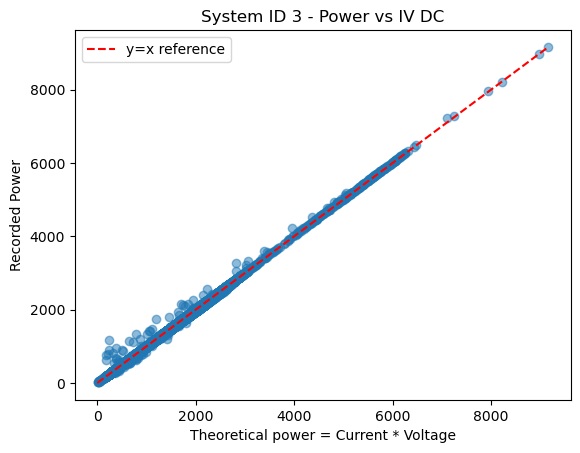

In [ ]:

#write down metric_ids for current, voltage, power for this system_id
# current_id = 348
# voltage_id = 347
# power_id = 346

power_common_name = metrics_df_filtered.loc[metrics_df_filtered['metric_id'] == power_id, 'common_name'].values[0]
id_path = Path(data_dir) / str(id)
df_metric

df_system = pd.read_parquet(id_path) #read it in
df_system =df_system.drop(columns=["utc_measured_on"]) #not interested
df_system = df_system.drop_duplicates() #don't want duplicates
df_system = df_system.loc[df_system['metric_id'].isin([current_id, voltage_id, power_id])] #only want relevant metric_ids

df_system_wide = df_system.pivot(index='measured_on', columns='metric_id', values='value')
#get rid of negative values
df_system_wide = df_system_wide[(df_system_wide[current_id] >= 1) & (df_system_wide[voltage_id] >= 1) & (df_system_wide[power_id] >= 1)]
df_system_wide

#make a power vs IV plot
plt.scatter(df_system_wide[current_id] * df_system_wide[voltage_id], df_system_wide[power_id], alpha=0.5)
plt.xlabel('Theoretical power = Current * Voltage')
plt.ylabel('Recorded Power')
plt.title(f'System ID {id} - Power vs IV {dc_or_ac}')

#also plot line y=x for reference
plt.plot([0, (df_system_wide[current_id] * df_system_wide[voltage_id]).max()], [0, (df_system_wide[current_id] * df_system_wide[voltage_id]).max()], color='red', linestyle='--', label='y=x reference')
plt.legend()

plt.show()


Ok now we'll try to iterate through everything that's nice.

What we'll have to do by hand:
- doesn't have all three of power, voltage, current for either ac or dc
- has too many readings

Now starting system_id 2
Step 1
Step 2
Step 3


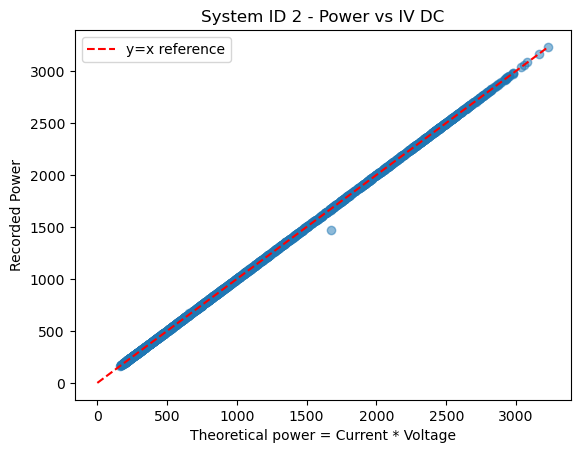

Now starting system_id 3
Step 1
Step 2
Step 3


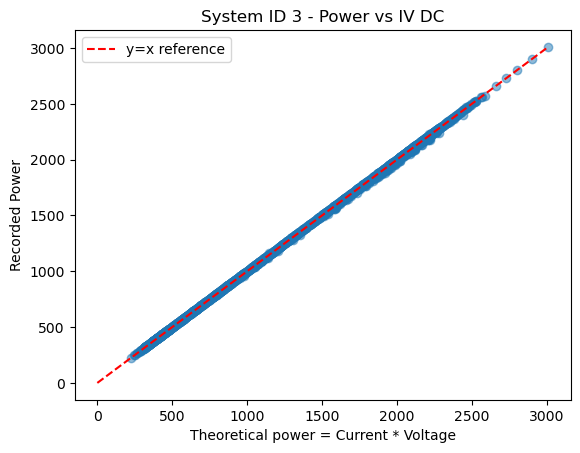

Now starting system_id 4
Step 1
Step 2
Step 3


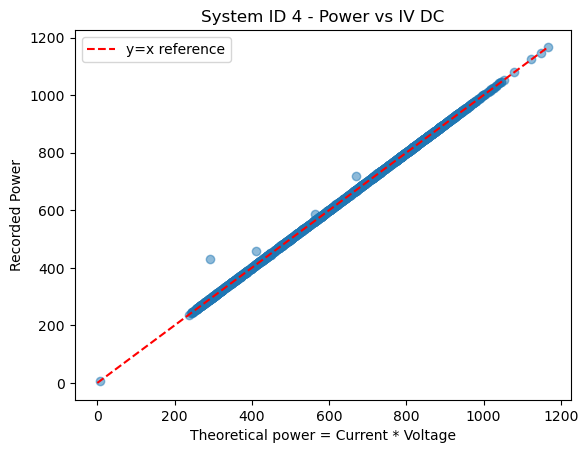

Now starting system_id 10
Step 1
Step 2
Step 3


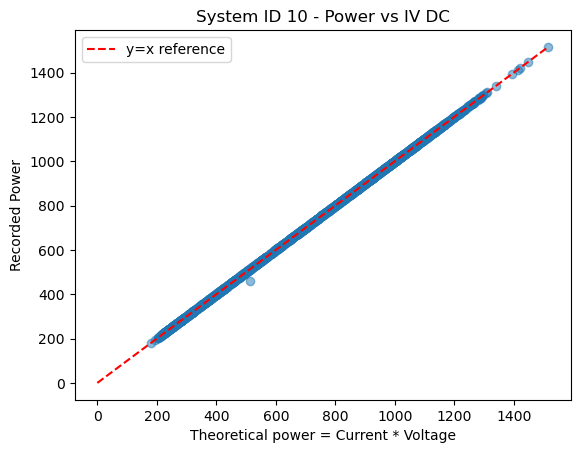

Now starting system_id 33
Step 1
Step 2
Step 3


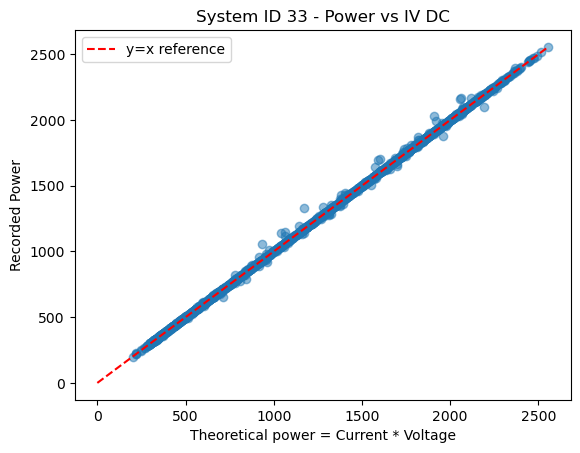

Now starting system_id 34
Step 1
Step 2
Step 3


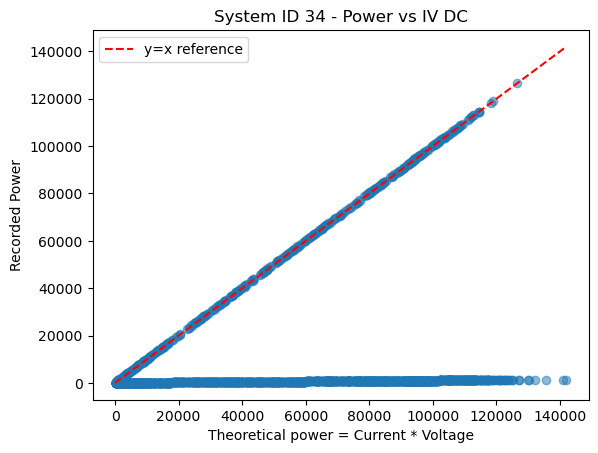

Now starting system_id 35
Step 1
Step 2
Step 3


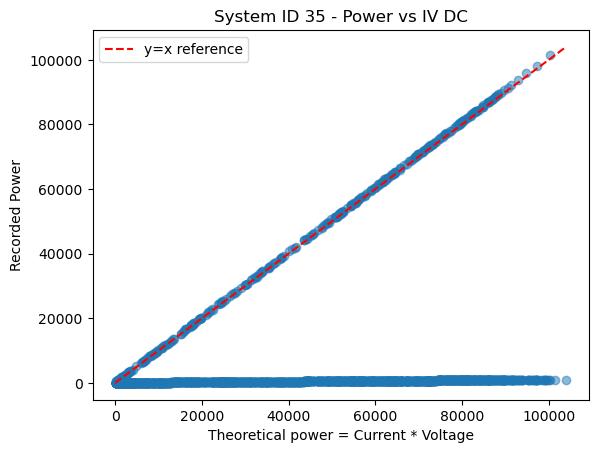

Now starting system_id 36
Step 1
Step 2
Step 3


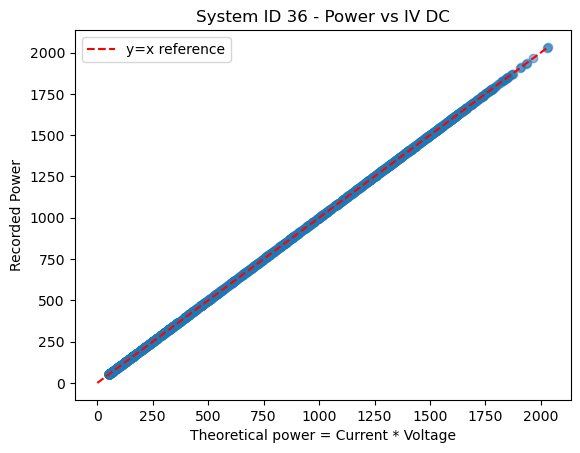

Now starting system_id 50
Step 1
Duplicate common names found for this system_id. Please check by hand.
Now starting system_id 51
Step 1
Duplicate common names found for this system_id. Please check by hand.
Now starting system_id 1199
Step 1
Duplicate common names found for this system_id. Please check by hand.
Now starting system_id 1200
Step 1
Duplicate common names found for this system_id. Please check by hand.
Now starting system_id 1201
Step 1
Step 2
Step 3


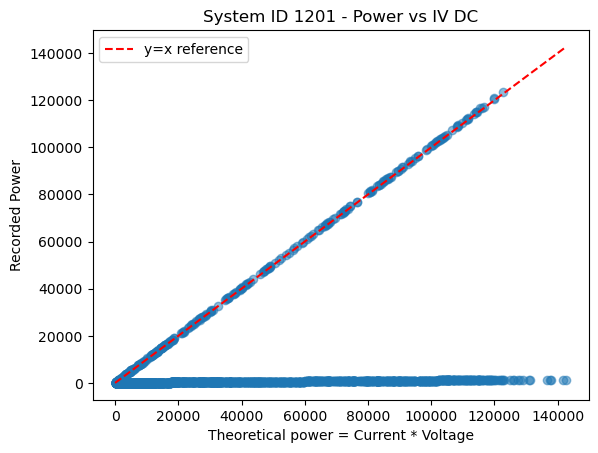

Now starting system_id 1202
Step 1
Duplicate common names found for this system_id. Please check by hand.
Now starting system_id 1203
Step 1
Duplicate common names found for this system_id. Please check by hand.
Now starting system_id 1204
Step 1
Duplicate common names found for this system_id. Please check by hand.
Now starting system_id 1207
Step 1
can't tell whether DC or AC - check by hand
Now starting system_id 1208
Step 1
Duplicate common names found for this system_id. Please check by hand.
Now starting system_id 1214
Step 1
can't tell whether DC or AC - check by hand
Now starting system_id 1216
Step 1
can't tell whether DC or AC - check by hand
Now starting system_id 1217
Step 1
can't tell whether DC or AC - check by hand
Now starting system_id 1218
Step 1
can't tell whether DC or AC - check by hand
Now starting system_id 1219
Step 1
can't tell whether DC or AC - check by hand
Now starting system_id 1220
Step 1
can't tell whether DC or AC - check by hand
Now starting system_id 

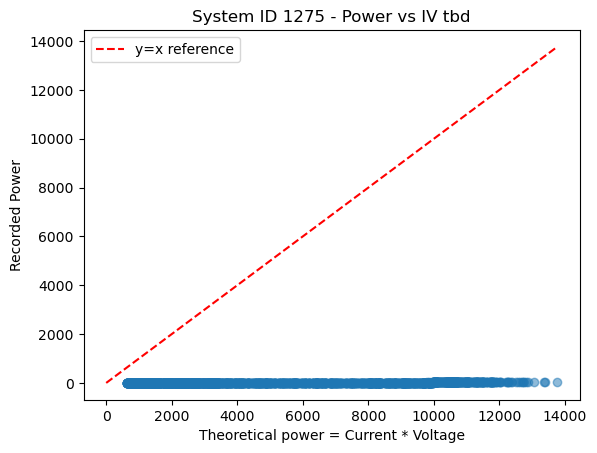

Now starting system_id 1276
Step 1
Step 2
Step 3


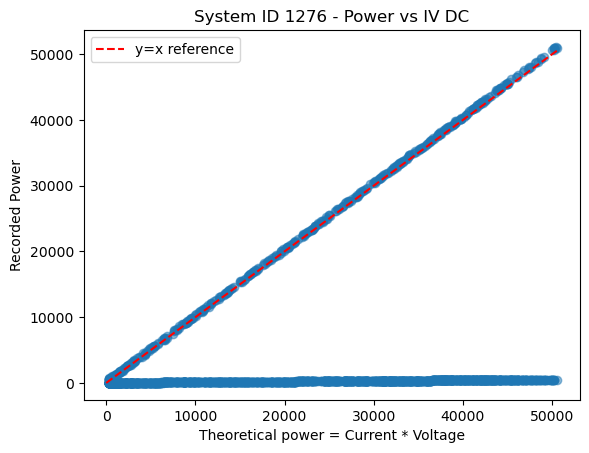

Now starting system_id 1277
Step 1
Step 2
Step 3


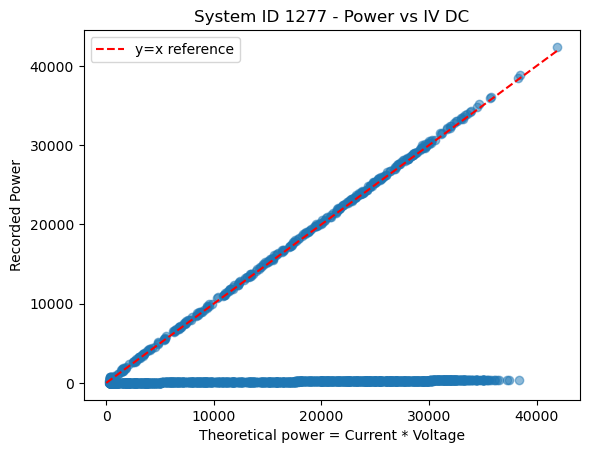

Now starting system_id 1278
Step 1
Duplicate common names found for this system_id. Please check by hand.
Now starting system_id 1283
Step 1
Duplicate common names found for this system_id. Please check by hand.
Now starting system_id 1284
Step 1
Step 2
Step 3


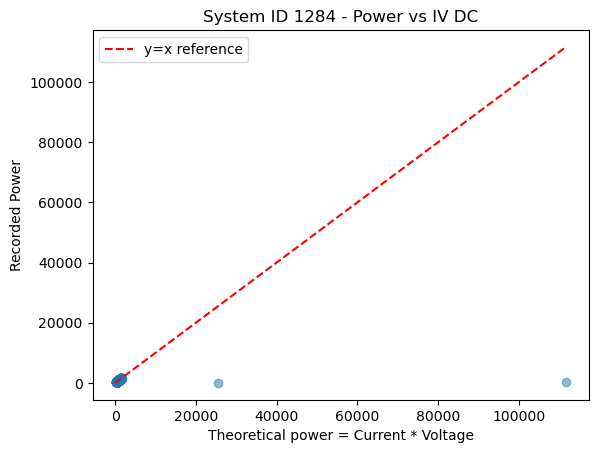

Now starting system_id 1289
Step 1
Step 2
Step 3


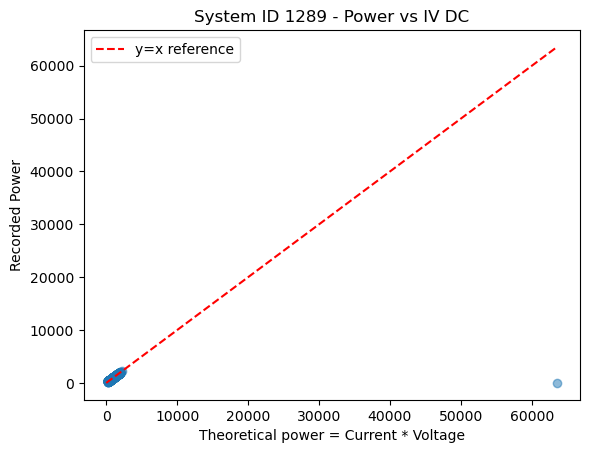

Now starting system_id 1294
Step 1
can't tell whether DC or AC - check by hand
Now starting system_id 1295
Step 1
can't tell whether DC or AC - check by hand
Now starting system_id 1296
Step 1
can't tell whether DC or AC - check by hand
Now starting system_id 1297
Step 1
can't tell whether DC or AC - check by hand
Now starting system_id 1298
Step 1
can't tell whether DC or AC - check by hand
Now starting system_id 1299
Step 1
can't tell whether DC or AC - check by hand
Now starting system_id 1300
Step 1
Step 2
Step 3


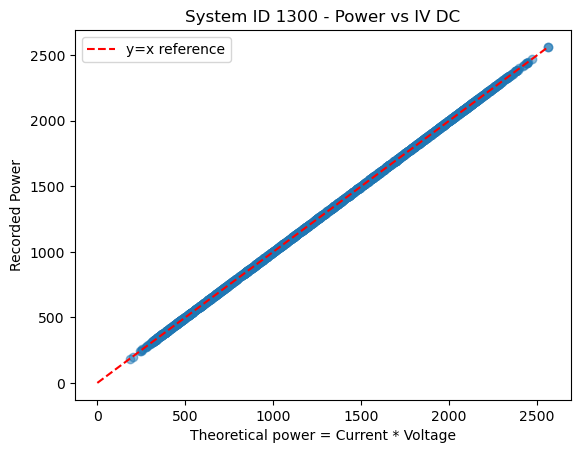

Now starting system_id 1301
Step 1
can't tell whether DC or AC - check by hand
Now starting system_id 1302
Step 1
can't tell whether DC or AC - check by hand
Now starting system_id 1303
Step 1
can't tell whether DC or AC - check by hand
Now starting system_id 1304
Step 1
can't tell whether DC or AC - check by hand
Now starting system_id 1305
Step 1
Duplicate common names found for this system_id. Please check by hand.
Now starting system_id 1306
Step 1
Duplicate common names found for this system_id. Please check by hand.
Now starting system_id 1307
Step 1
Duplicate common names found for this system_id. Please check by hand.
Now starting system_id 1308
Step 1
Duplicate common names found for this system_id. Please check by hand.
Now starting system_id 1309
Step 1
can't tell whether DC or AC - check by hand
Now starting system_id 1310
Step 1
Duplicate common names found for this system_id. Please check by hand.
Now starting system_id 1311
Step 1
can't tell whether DC or AC - check by h

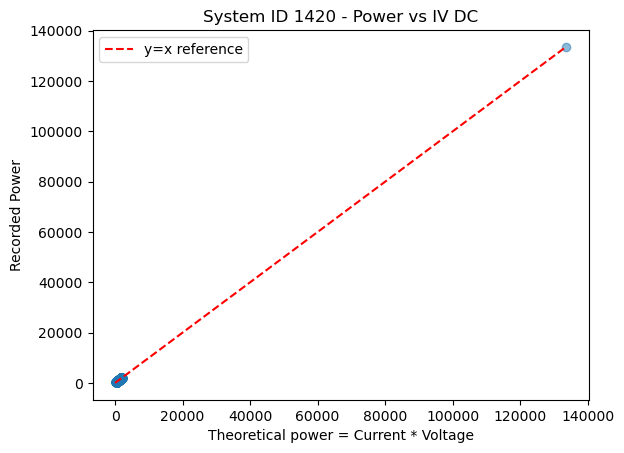

Now starting system_id 1422
Step 1
Duplicate common names found for this system_id. Please check by hand.
Now starting system_id 1423
Step 1
Duplicate common names found for this system_id. Please check by hand.
Now starting system_id 1429
Step 1
Duplicate common names found for this system_id. Please check by hand.
Now starting system_id 1430
Step 1
Step 2
Step 3


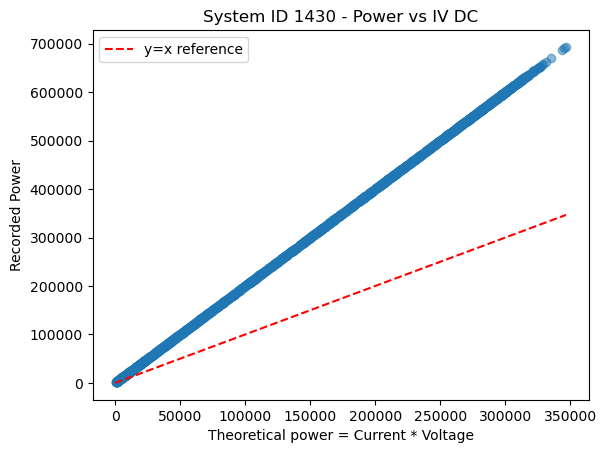

Now starting system_id 1431
Step 1
Step 2
Step 3


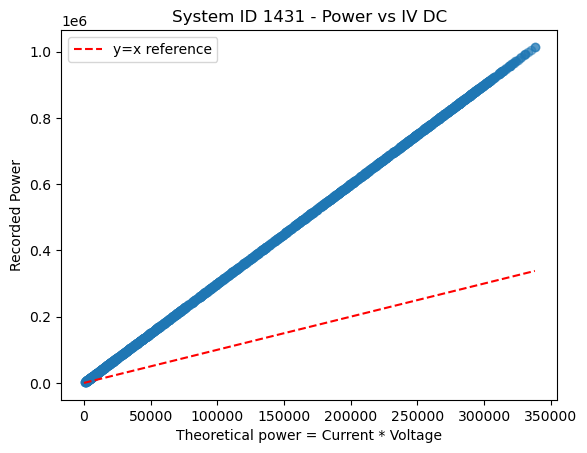

Now starting system_id 1432
Step 1
can't tell whether DC or AC - check by hand
Now starting system_id 1433
Step 1
can't tell whether DC or AC - check by hand
Now starting system_id 4901
Step 1
can't tell whether DC or AC - check by hand
Now starting system_id 4902
Step 1
can't tell whether DC or AC - check by hand
Now starting system_id 4903
Step 1
can't tell whether DC or AC - check by hand


[(50, 'duplicate'),
 (51, 'duplicate'),
 (1199, 'duplicate'),
 (1200, 'duplicate'),
 (1202, 'duplicate'),
 (1203, 'duplicate'),
 (1204, 'duplicate'),
 (1207, "can't find P,I,V"),
 (1208, 'duplicate'),
 (1214, "can't find P,I,V"),
 (1216, "can't find P,I,V"),
 (1217, "can't find P,I,V"),
 (1218, "can't find P,I,V"),
 (1219, "can't find P,I,V"),
 (1220, "can't find P,I,V"),
 (1221, "can't find P,I,V"),
 (1222, "can't find P,I,V"),
 (1223, "can't find P,I,V"),
 (1224, "can't find P,I,V"),
 (1225, "can't find P,I,V"),
 (1226, "can't find P,I,V"),
 (1228, "can't find P,I,V"),
 (1229, "can't find P,I,V"),
 (1230, "can't find P,I,V"),
 (1231, "can't find P,I,V"),
 (1239, "can't find P,I,V"),
 (1244, "can't find P,I,V"),
 (1245, "can't find P,I,V"),
 (1246, "can't find P,I,V"),
 (1248, "can't find P,I,V"),
 (1249, "can't find P,I,V"),
 (1250, "can't find P,I,V"),
 (1252, "can't find P,I,V"),
 (1253, "can't find P,I,V"),
 (1254, "can't find P,I,V"),
 (1255, "can't find P,I,V"),
 (1256, "can't f

In [75]:
do_by_hand = []
errors = []
for id in system_ids:
    state = random.randint(1,500)
    try:
        print(f'Now starting system_id {id}')
        df_metric = metrics_df_filtered.loc[metrics_df_filtered['system_id'] == id]

        dc_or_ac = 'tbd' 

        #   Step 1: find metric_ids for current, voltage, power for this system_id
        print('Step 1')
        # if df_metric['common_name'].duplicated().any():
        #     print('Duplicate common names found for this system_id. Please check by hand.')
        #     do_by_hand.append((id,"duplicate"))
        #     continue
        # else:
        #     if ('DC power' in df_metric['common_name'].values) & ('DC current' in df_metric['common_name'].values) & ('DC voltage' in df_metric['common_name'].values):
        #         current_id = df_metric.loc[df_metric['common_name'] == 'DC current', 'metric_id'].values[0]
        #         voltage_id = df_metric.loc[df_metric['common_name'] == 'DC voltage', 'metric_id'].values[0]
        #         power_id = df_metric.loc[df_metric['common_name'] == 'DC power', 'metric_id'].values[0]
        #         dc_or_ac = 'DC'
        #     elif ('AC power' in df_metric['common_name'].values) & ('AC current' in df_metric['common_name'].values) & ('AC voltage' in df_metric['common_name'].values):
        #         dc_or_ac = 'AC'
        #         current_id = df_metric.loc[df_metric['common_name'] == 'AC current', 'metric_id'].values[0]
        #         voltage_id = df_metric.loc[df_metric['common_name'] == 'AC voltage', 'metric_id'].values[0]
        #         power_id = df_metric.loc[df_metric['common_name'] == 'AC power', 'metric_id'].values[0]
        #     else:
        #         print("can't tell whether DC or AC - check by hand")
        #         do_by_hand.append((id,"can't find P,I,V"))
        #         continue
        if ('DC power' in df_metric['common_name'].values) & ('DC current' in df_metric['common_name'].values) & ('DC voltage' in df_metric['common_name'].values):
            #want to make sure there's only one of each 
            counts = df_metric['common_name'].value_counts()
            if (counts['DC power'] > 1) | (counts['DC current'] > 1) | (counts['DC voltage'] > 1):
                print('Duplicate common names found for this system_id. Please check by hand.')
                do_by_hand.append((id,"duplicate"))
                continue

            current_id = df_metric.loc[df_metric['common_name'] == 'DC current', 'metric_id'].values[0]
            voltage_id = df_metric.loc[df_metric['common_name'] == 'DC voltage', 'metric_id'].values[0]
            power_id = df_metric.loc[df_metric['common_name'] == 'DC power', 'metric_id'].values[0]
            dc_or_ac = 'DC'
        elif ('AC power' in df_metric['common_name'].values) & ('AC current' in df_metric['common_name'].values) & ('AC voltage' in df_metric['common_name'].values):
            #want to make sure there's only one of each
            counts = df_metric['common_name'].value_counts()
            if (counts['AC power'] > 1) | (counts['AC current'] > 1) | (counts['AC voltage'] > 1):
                print('Duplicate common names found for this system_id. Please check by hand.')
                do_by_hand.append((id,"duplicate"))
                continue

            current_id = df_metric.loc[df_metric['common_name'] == 'AC current', 'metric_id'].values[0]
            voltage_id = df_metric.loc[df_metric['common_name'] == 'AC voltage', 'metric_id'].values[0]
            power_id = df_metric.loc[df_metric['common_name'] == 'AC power', 'metric_id'].values[0]
        else:
            print("can't tell whether DC or AC - check by hand")
            do_by_hand.append((id,"can't find P,I,V"))
            continue
        #print(current_id, voltage_id, power_id, dc_or_ac)

        #   Step 2: read in the parquet file for this system_id, filter to only include rows with the relevant metric_ids, pivot to wide format
        print('Step 2')
        power_common_name = metrics_df_filtered.loc[metrics_df_filtered['metric_id'] == power_id, 'common_name'].values[0]
        id_path = Path(data_dir) / str(id)
        df_metric

        df_system = pd.read_parquet(id_path) #read it in
        df_system =df_system.drop(columns=["utc_measured_on"]) #not interested
        df_system = df_system.drop_duplicates() #don't want duplicates
        df_system = df_system.loc[df_system['metric_id'].isin([current_id, voltage_id, power_id])] #only want relevant metric_ids
        #still have some duplicate time/metric_id pairs. Want to replace each value with the mean of the values of tht time with that id
        df_system = df_system.groupby(['measured_on', 'metric_id']).mean().reset_index()

        df_system_wide = df_system.pivot(index='measured_on', columns='metric_id', values='value')
        #get rid of negative/small values
        df_system_wide = df_system_wide[(df_system_wide[current_id] >= 1) & (df_system_wide[voltage_id] >= 1) & (df_system_wide[power_id] >= 1)]

        #   Step 3: make a power vs IV plot for this system_id
        print('Step 3')

        #at this point, it's important to see whether power is in watts or kilowatts
        power_unit = df_metric.loc[df_metric['metric_id'] == power_id, 'units'].values[0]
        multiplierPower = 1
        if power_unit == 'kW':
            multiplierPower = 1000

        #need to reduce number of data points!!! will do 2000 for now 
        df_system_wide = df_system_wide.sample(n=2000, random_state=state)
        plt.scatter(df_system_wide[current_id] * df_system_wide[voltage_id], df_system_wide[power_id] * multiplierPower, alpha=0.5)
        plt.xlabel('Theoretical power = Current * Voltage')
        plt.ylabel('Recorded Power')
        plt.title(f'System ID {id} - Power vs IV {dc_or_ac}')

        #also plot line y=x for reference
        plt.plot([0, (df_system_wide[current_id] * df_system_wide[voltage_id]).max()], [0, (df_system_wide[current_id] * df_system_wide[voltage_id]).max()], color='red', linestyle='--', label='y=x reference')
        plt.legend()

        plt.show()
    except Exception as e:
        print(f'Error processing system_id {id}: {e}')
        errors.append((id, str(e)))
        
do_by_hand
#note: this threw no errors and took appx 14 minutes to run

There were a bunch where P,I,V weren't found. Let's see if there are more key words missing...

In [73]:
for id, reason in do_by_hand:
    if reason == "can't find P,I,V":
        print(f'\nsystem_id={id}')
        display(metrics_df_filtered.loc[metrics_df_filtered['system_id'] == id])
        #print('\t',metrics_df_filtered.loc[metrics_df_filtered['system_id'] == id])
# id = 1271
# df_metric = metrics_df_filtered.loc[metrics_df_filtered['system_id'] == id]
# df_metric


system_id=1207


,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
208,1207,2622,dc_power,DC power,W,W,1.0,0.0,,avg,NaN,NaN,,dc_power__2622
209,1207,2633,poa_irradiance,Irradiance POA,W/m^2,W/m^2,1.0,0.0,,avg,NaN,NaN,,poa_irradiance__2633
210,1207,2629,module_temp,Temperature module,C,C,1.0,0.0,,avg,NaN,NaN,,module_temp__2629
211,1207,2623,dc_power_A1,DC power,-,-,1.0,0.0,,NaN,NaN,NaN,,dc_power_a1__2623
212,1207,2624,dc_power_A2,DC power,-,-,1.0,0.0,,NaN,NaN,NaN,,dc_power_a2__2624
213,1207,2625,dc_power_B1,DC power,-,-,1.0,0.0,,NaN,NaN,NaN,,dc_power_b1__2625
214,1207,2626,dc_power_B2,DC power,-,-,1.0,0.0,,NaN,NaN,NaN,,dc_power_b2__2626
215,1207,2627,dc_power_C1,DC power,-,-,1.0,0.0,,NaN,NaN,NaN,,dc_power_c1__2627
216,1207,2628,dc_power_C2,DC power,-,-,1.0,0.0,,NaN,NaN,NaN,,dc_power_c2__2628
217,1207,2630,poa_irradiance_cs300_1,Irradiance POA,W/m^2,W/m^2,1.0,0.0,,NaN,NaN,NaN,,poa_irradiance_cs300_1__2630



system_id=1214


,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
239,1214,3185,A_avg,AC current other,A,A,1.000,0.0,,avg,NaN,NaN,,a_avg__3185
240,1214,3184,PPV_avg,AC voltage,V,V,1.000,0.0,,avg,NaN,NaN,,ppv_avg__3184
241,1214,3183,W_avg,AC power,W,W,1.000,0.0,,avg,NaN,NaN,,w_avg__3183
242,1214,3182,Wh_sum,AC energy,kWh,kWh,0.001,0.0,,sum,NaN,NaN,,wh_sum__3182



system_id=1216


...

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1392,4901,82498,AmbTemp_C_Avg,Temperature ambient,C,C,1.0,0.0,,avg,OTHER,2200.0,,temperature_ambient_o_2200
1393,4901,82575,Battery_A_Avg,DC current battery,A,A,1.0,0.0,,avg,,NaN,,battery_a_avg__82575
1394,4901,82574,Battery_V_Min,DC voltage battery,V,V,1.0,0.0,,min,,NaN,,battery_v_min__82574
1395,4901,82491,CR1000Temp_C_Avg,Temperature enclosure,C,C,1.0,0.0,,avg,OTHER,NaN,,cr1000temp_c_avg__82491
1396,4901,82578,ChgSource_Min,Battery other,-,-,1.0,0.0,,min,,NaN,,chgsource_min__82578
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1487,4901,82580,Qloss_Ah_Max,System other,Ah,Ah,1.0,0.0,,max,,NaN,,qloss_ah_max__82580
1488,4901,82524,SEWSPOAIrrad_Wm2_Avg,System other,W/m^2,W/m^2,1.0,0.0,,avg,,2201.0,,sewspoairrad_wm2_avg__82524
1489,4901,82568,WindDirAve_deg,AC other,Deg,Deg,1.0,0.0,,wvc,OTHER,2201.0,,wind_direction_o_2201
1490,4901,82569,WindDirStdDev_deg,AC other,Deg,Deg,1.0,0.0,,wvc,OTHER,2201.0,,wind_other_o_2201



system_id=4902


,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1492,4902,82596,AmbTemp_C_Avg,Temperature ambient,C,C,1.0,0.0,,avg,OTHER,2205.0,,temperature_ambient_o_2205
1493,4902,82673,Battery_A_Avg,DC current battery,A,A,1.0,0.0,,avg,,NaN,,battery_a_avg__82673
1494,4902,82672,Battery_V_Min,DC voltage battery,V,V,1.0,0.0,,min,,NaN,,battery_v_min__82672
1495,4902,82591,CR1000Temp_C_Avg,Temperature enclosure,C,C,1.0,0.0,,avg,OTHER,NaN,,cr1000temp_c_avg__82591
1496,4902,82676,ChgSource_Min,Battery other,-,-,1.0,0.0,,min,,NaN,,chgsource_min__82676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1585,4902,82625,PwrMtrIc_Avg,System other,A,A,1.0,0.0,,avg,METER,1864.0,,system_other_meter_1864_3
1586,4902,82678,Qloss_Ah_Max,System other,Ah,Ah,1.0,0.0,,max,,NaN,,qloss_ah_max__82678
1587,4902,82666,WindDirAve_deg,AC other,Deg,Deg,1.0,0.0,,wvc,OTHER,2206.0,,wind_direction_o_2206
1588,4902,82667,WindDirStdDev_deg,AC other,Deg,Deg,1.0,0.0,,wvc,OTHER,2206.0,,wind_other_o_2206



system_id=4903


,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1590,4903,82702,AmbTemp_C_Avg,Temperature ambient,C,C,1.0,0.0,,avg,OTHER,2217.0,,temperature_ambient_o_2217
1591,4903,82785,Battery_A_Avg,DC current battery,A,A,1.0,0.0,,avg,,NaN,,battery_a_avg__82785
1592,4903,82784,Battery_V_Min,DC voltage battery,V,V,1.0,0.0,,min,,NaN,,battery_v_min__82784
1593,4903,82689,CR1000Temp_C_Avg,Temperature enclosure,C,C,1.0,0.0,,avg,OTHER,NaN,,cr1000temp_c_avg__82689
1594,4903,82788,ChgSource_Min,Battery other,-,-,1.0,0.0,,min,,NaN,,chgsource_min__82788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1706,4903,82743,SEWSPOAIrrad_Wm2_Avg,System other,W/m^2,W/m^2,1.0,0.0,,avg,OTHER,2218.0,,system_other_o_2218
1707,4903,82710,Warnings_Max,System other,-,-,1.0,0.0,,max,INVERTER,14539.0,,system_other_inv_14539_14
1708,4903,82778,WindDirAve_deg,AC other,Deg,Deg,1.0,0.0,,wvc,OTHER,2218.0,,wind_direction_o_2218
1709,4903,82779,WindDirStdDev_deg,AC other,Deg,Deg,1.0,0.0,,wvc,OTHER,2218.0,,wind_other_o_2218


observations:
- AC current other
- AC other (check the units -- system 1216 had this as power)